In [1]:
import os
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split

# Ensure directory for saved models exists
os.makedirs("models", exist_ok=True)

# Load Dataset
data_path = "data/diabetes_health_indicators.csv"
df = pd.read_csv(data_path)

print("✅ Dataset loaded successfully.")
print(f"Total Rows: {df.shape[0]}, Total Features: {df.shape[1]}")

✅ Dataset loaded successfully.
Total Rows: 253680, Total Features: 22


In [2]:
# Separate target and features
target_col = "Diabetes_binary"
X = df.drop(columns=[target_col])
y = df[target_col]

# Clean optional metadata columns if present
if "ID" in X.columns:
    X = X.drop(columns=["ID"])

# Train-Test Split (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

Training set: 202944 samples
Testing set: 50736 samples


In [3]:
# Initialize Random Forest with controlled depth to prevent overfitting
rf_model = RandomForestClassifier(
    n_estimators=150, max_depth=10, random_state=42, n_jobs=-1
)

# Fit model
rf_model.fit(X_train, y_train)
print("✅ Random Forest training complete.")

✅ Random Forest training complete.


In [4]:
# Generate predictions
y_pred = rf_model.predict(X_test)

# Calculate metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=" * 40)
print("       RANDOM FOREST PERFORMANCE       ")
print("=" * 40)
print(f"Accuracy  : {acc*100:.2f}%")
print(f"Precision : {prec*100:.2f}%")
print(
    f"Recall    : {rec*100:.2f}% <-- Critical for Minimizing False Negatives"
)
print(f"F1 Score  : {f1*100:.2f}%\n")

print("Detailed Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

       RANDOM FOREST PERFORMANCE       
Accuracy  : 86.43%
Precision : 58.60%
Recall    : 8.77% <-- Critical for Minimizing False Negatives
F1 Score  : 15.26%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.99      0.93     43667
           1       0.59      0.09      0.15      7069

    accuracy                           0.86     50736
   macro avg       0.73      0.54      0.54     50736
weighted avg       0.83      0.86      0.82     50736

Confusion Matrix:
[[43229   438]
 [ 6449   620]]


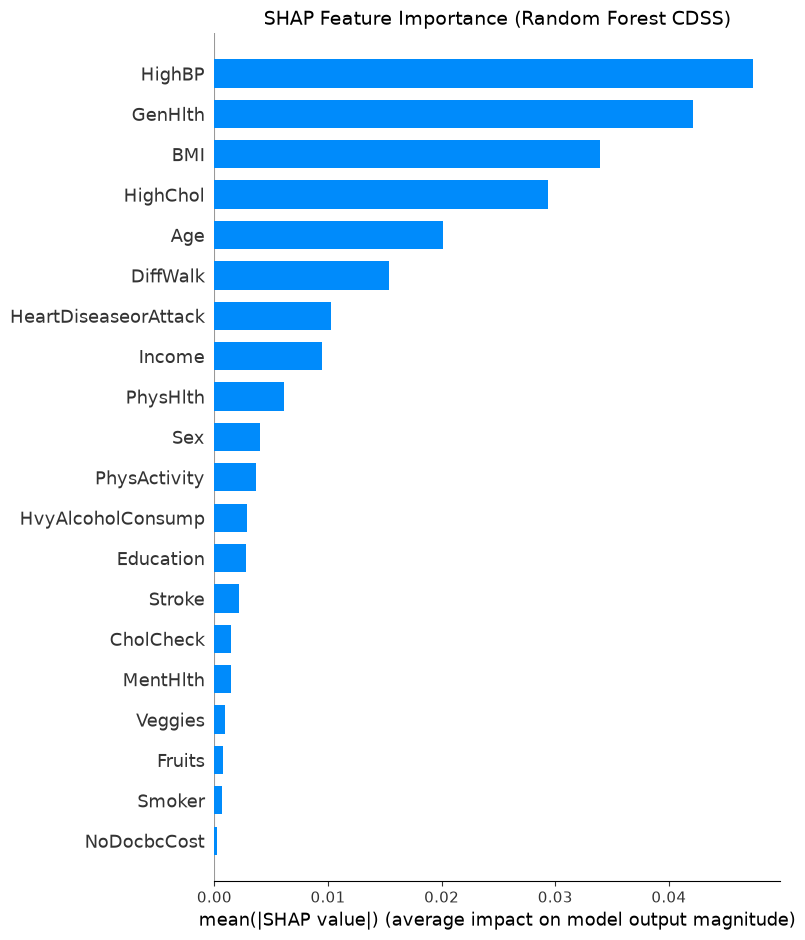

In [5]:
# Create TreeExplainer for Random Forest
explainer = shap.TreeExplainer(rf_model)

# Compute SHAP values for test samples (sample first 500 for speed if dataset is large)
sample_size = min(500, X_test.shape[0])
X_shap_sample = X_test.iloc[:sample_size]
shap_values = explainer.shap_values(X_shap_sample)

# Extract positive class SHAP values
if isinstance(shap_values, list):
    vals = shap_values[1]
else:
    vals = (
        shap_values[:, :, 1] if len(shap_values.shape) == 3 else shap_values
    )

# Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(vals, X_shap_sample, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Random Forest CDSS)", fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
# Save model and feature names for Streamlit integration
model_file = "models/diabetes_model.pkl"
feature_file = "models/model_features.pkl"

joblib.dump(rf_model, model_file)
joblib.dump(list(X.columns), feature_file)

print(f"✅ Model saved to: {model_file}")
print(f"✅ Feature list saved to: {feature_file}")

✅ Model saved to: models/diabetes_model.pkl
✅ Feature list saved to: models/model_features.pkl


In [7]:
!pip install seaborn


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


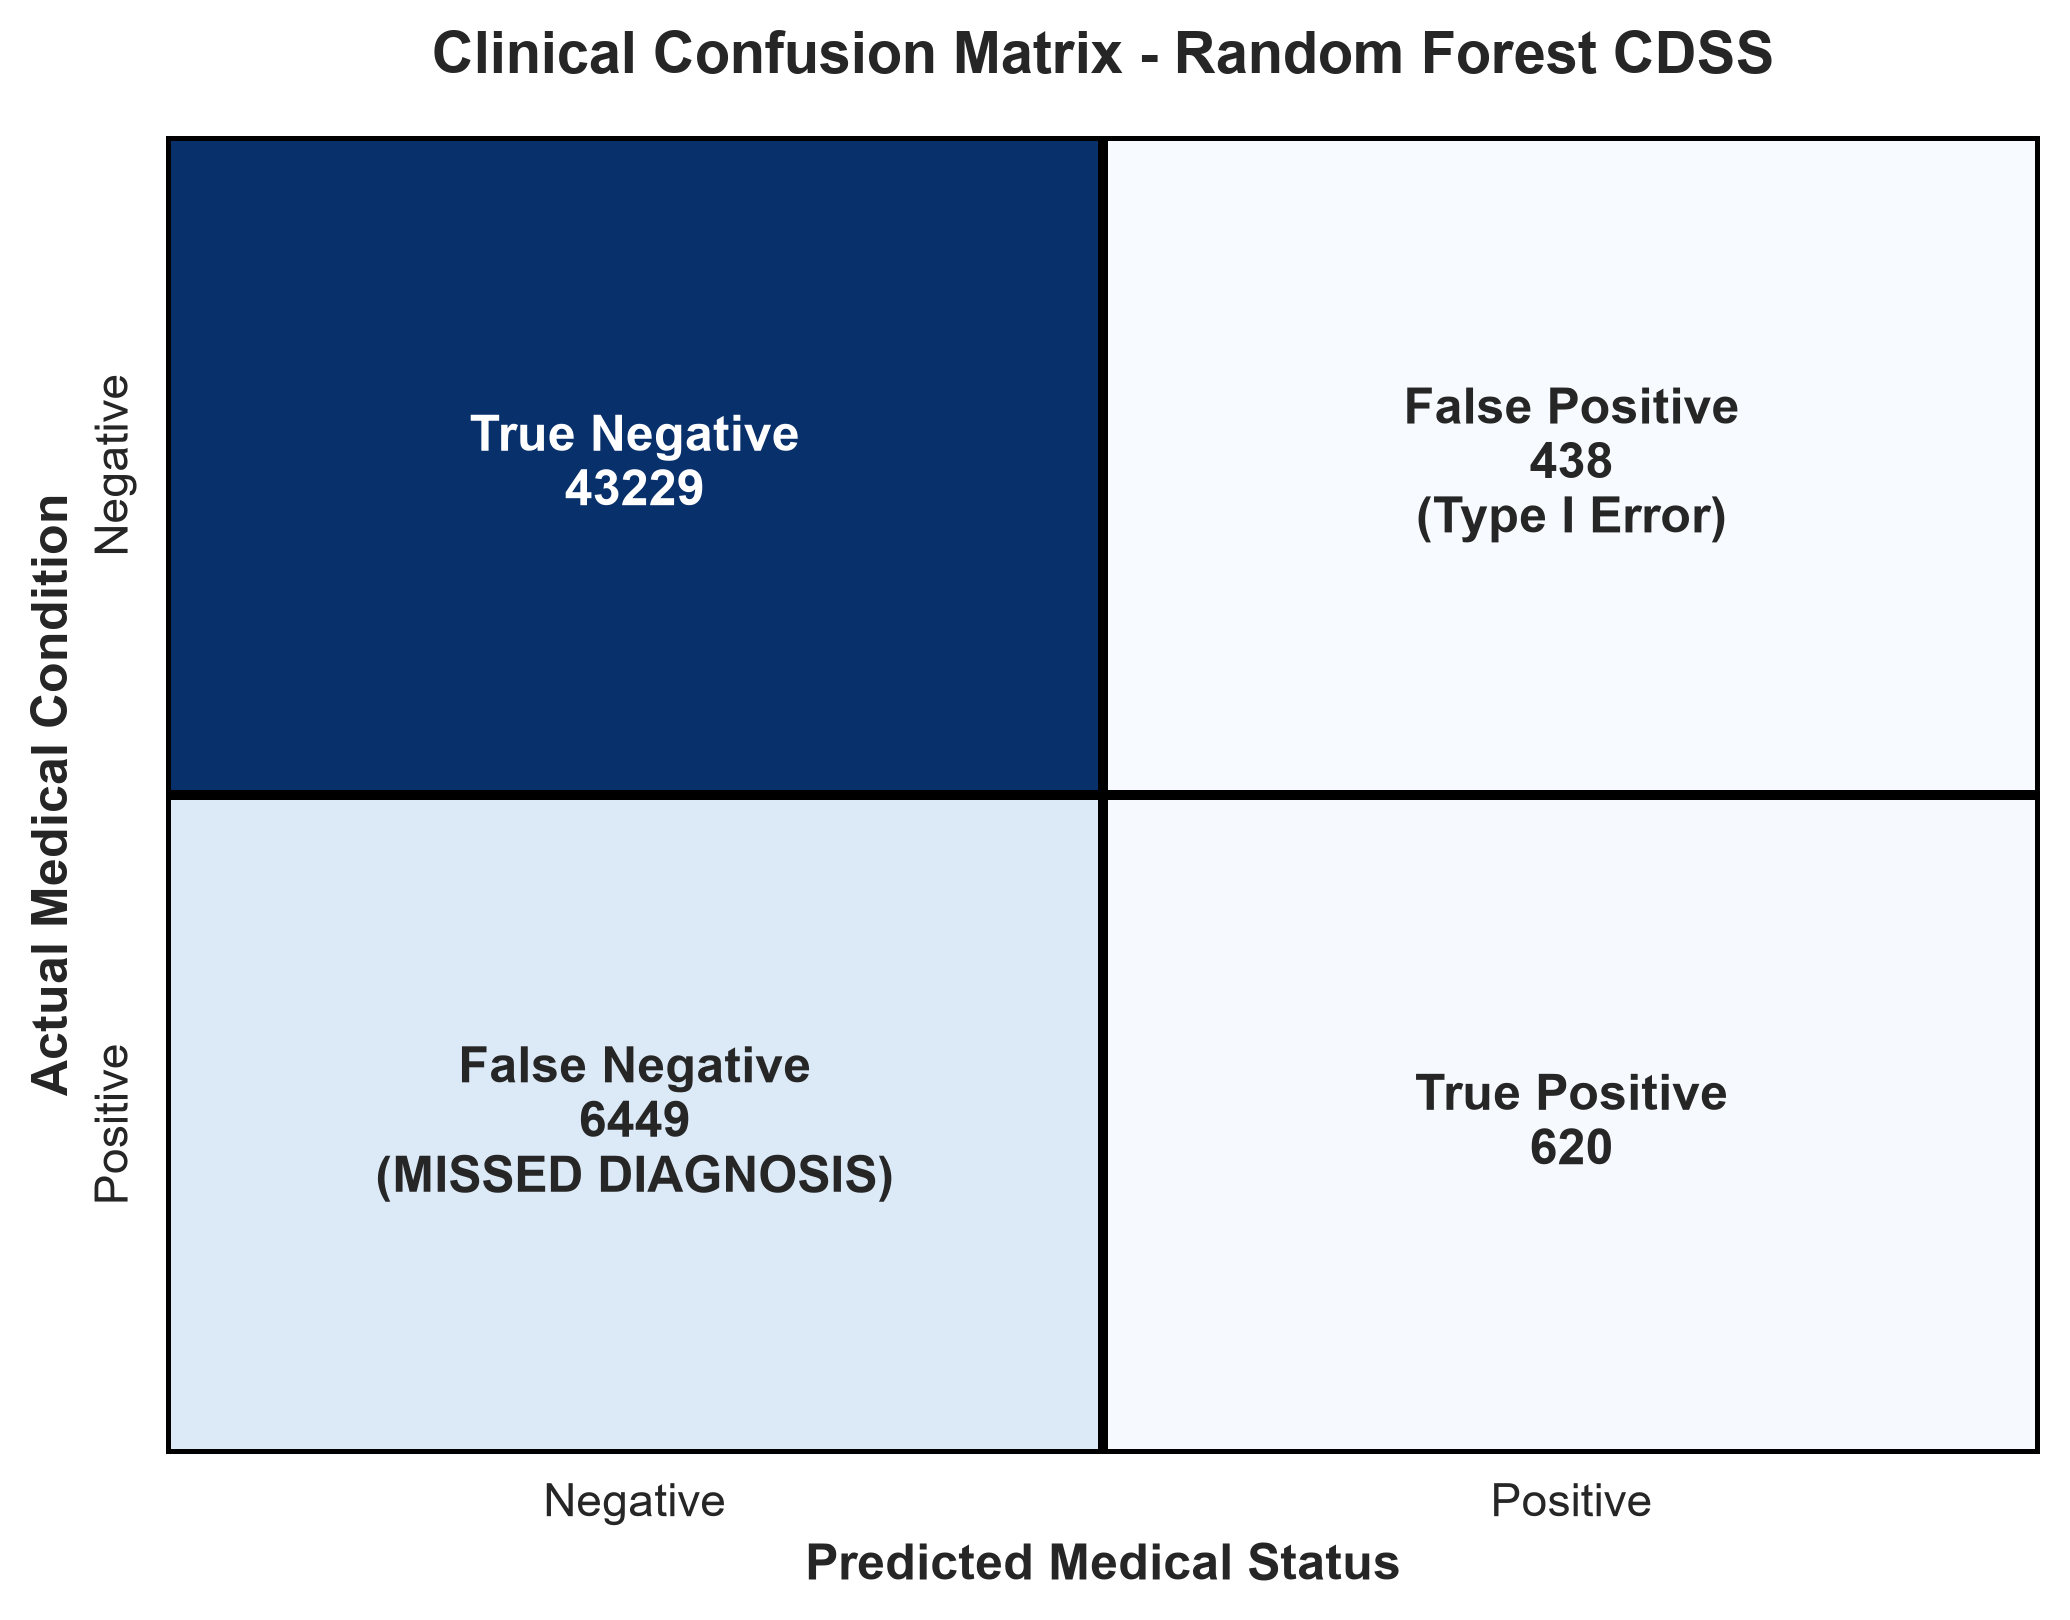

Saved high-res image: models/confusion_matrix_ppt.png


In [8]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Set PPT-Friendly Dark/Blue Theme
plt.figure(figsize=(7, 5.5), dpi=300)
sns.set_style("white")

# Plot Heatmap with Custom Annotations
labels = [
    [
        f"True Negative\n{cm[0,0]}",
        f"False Positive\n{cm[0,1]}\n(Type I Error)",
    ],
    [
        f"False Negative\n{cm[1,0]}\n(MISSED DIAGNOSIS)",
        f"True Positive\n{cm[1,1]}",
    ],
]

ax = sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues",
    cbar=False,
    linewidths=2,
    linecolor="black",
    annot_kws={"size": 12, "weight": "bold"},
)

plt.title(
    "Clinical Confusion Matrix - Random Forest CDSS",
    fontsize=14,
    weight="bold",
    pad=15,
)
plt.xlabel("Predicted Medical Status", fontsize=12, weight="bold")
plt.ylabel("Actual Medical Condition", fontsize=12, weight="bold")
ax.set_xticklabels(["Negative", "Positive"], fontsize=11)
ax.set_yticklabels(["Negative", "Positive"], fontsize=11)

plt.tight_layout()
plt.savefig("models/confusion_matrix_ppt.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved high-res image: models/confusion_matrix_ppt.png")

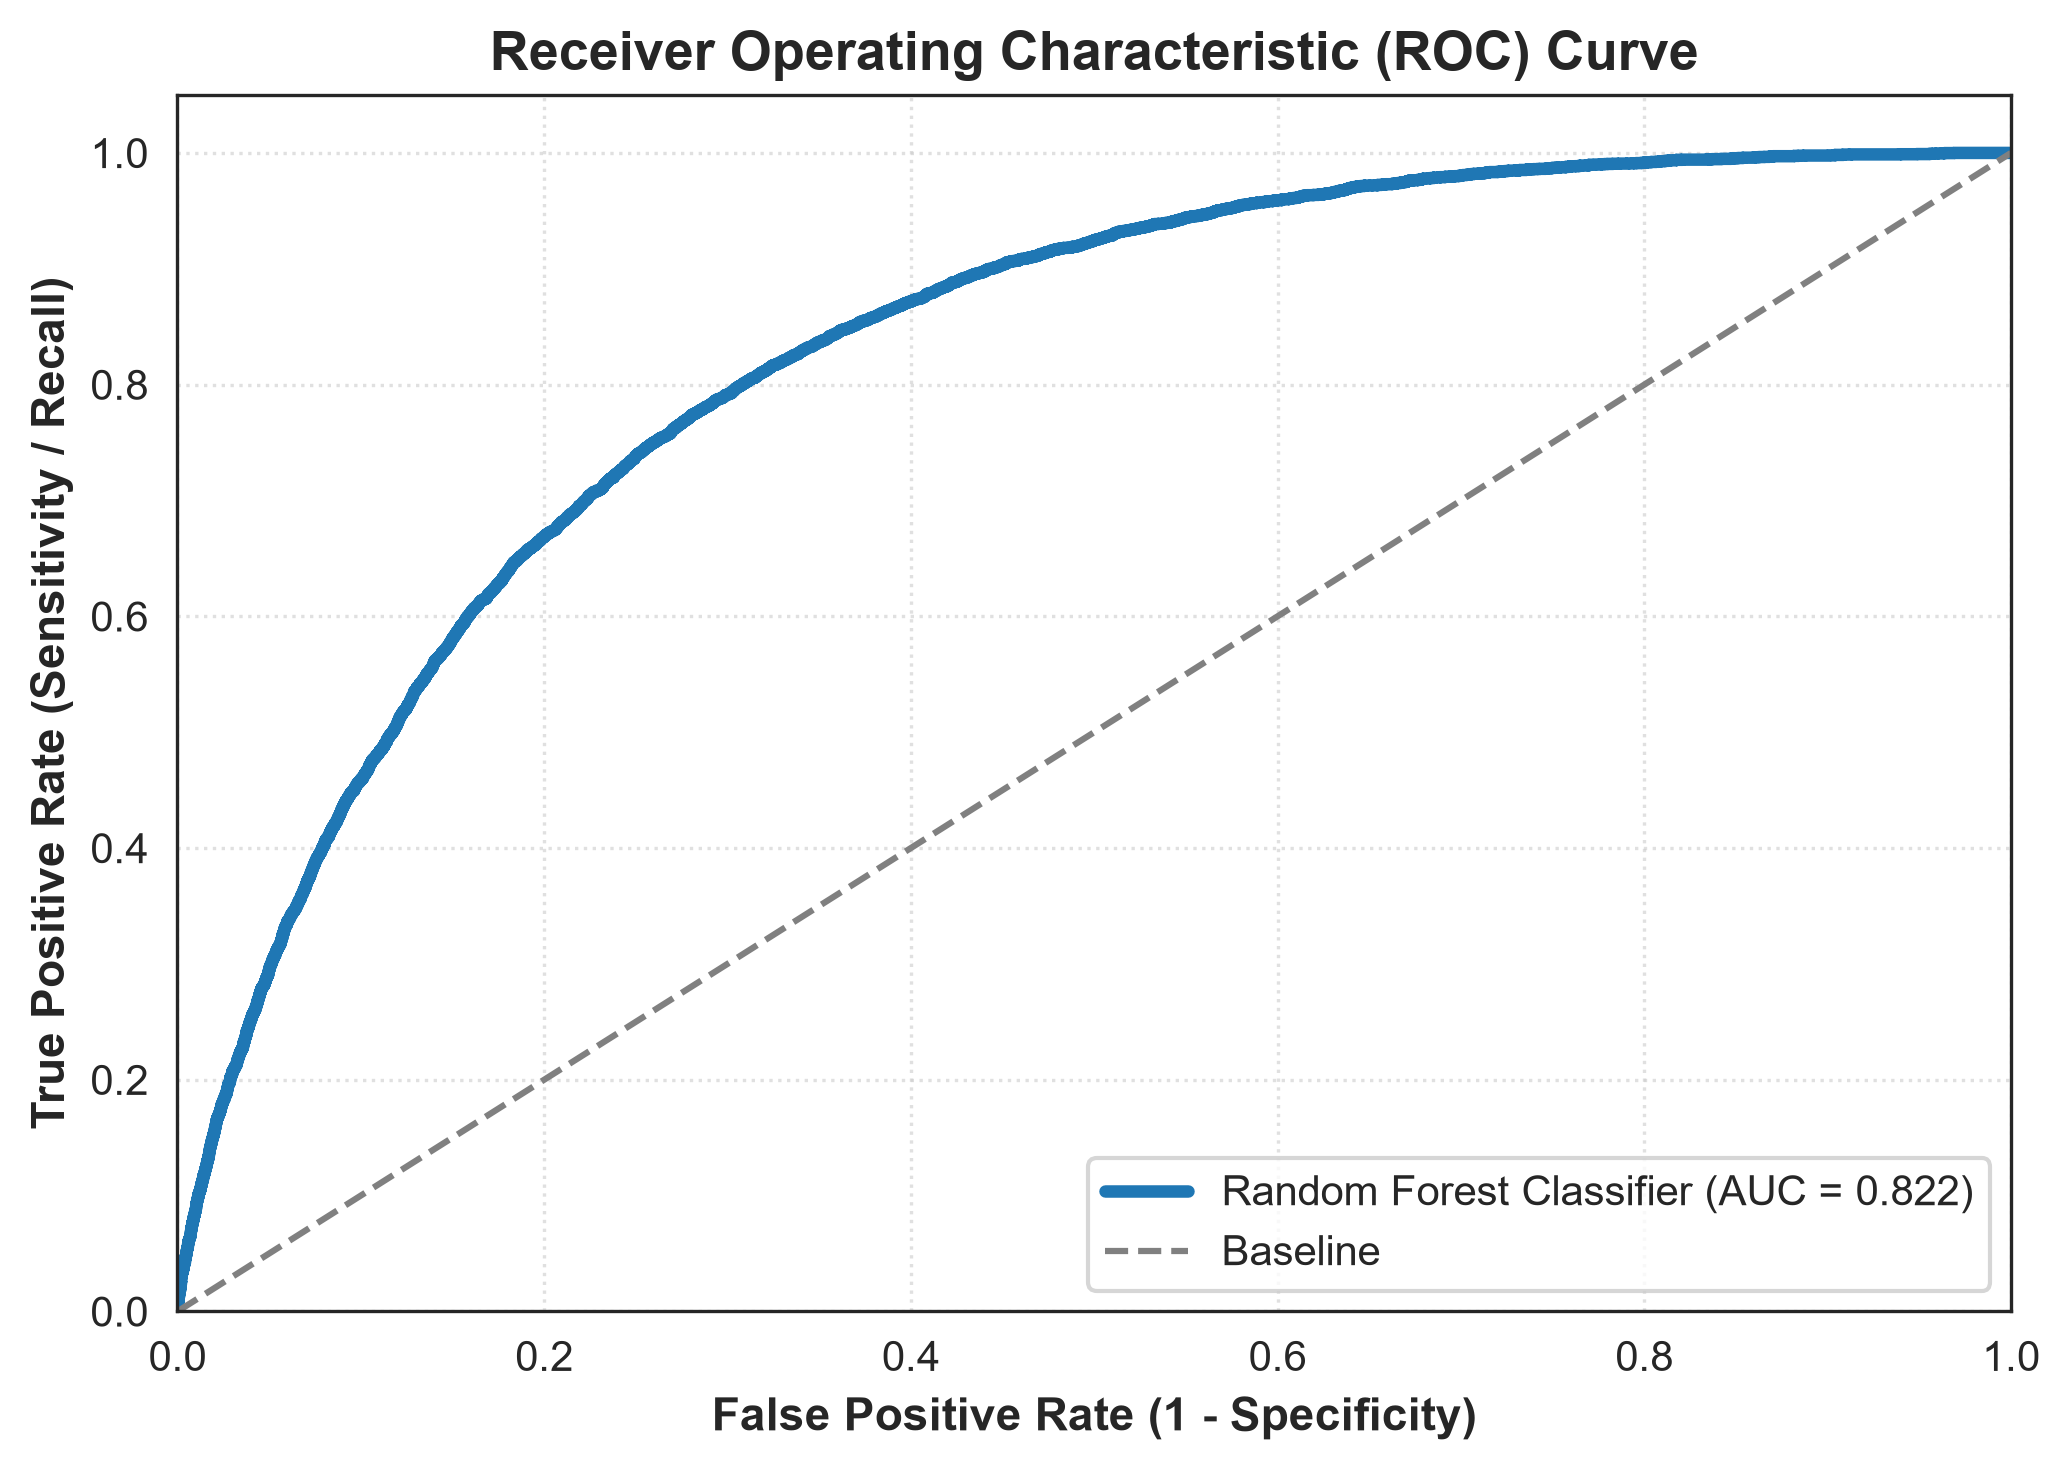

Saved high-res image: models/roc_curve_ppt.png


In [9]:
from sklearn.metrics import auc, roc_curve

# Calculate ROC metrics
y_proba = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5), dpi=300)
plt.plot(
    fpr,
    tpr,
    color="#1f77b4",
    lw=3,
    label=f"Random Forest Classifier (AUC = {roc_auc:.3f})",
)
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1.5, label="Baseline")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel(
    "False Positive Rate (1 - Specificity)", fontsize=11, weight="bold"
)
plt.ylabel("True Positive Rate (Sensitivity / Recall)", fontsize=11, weight="bold")
plt.title(
    "Receiver Operating Characteristic (ROC) Curve",
    fontsize=13,
    weight="bold",
)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.savefig("models/roc_curve_ppt.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved high-res image: models/roc_curve_ppt.png")

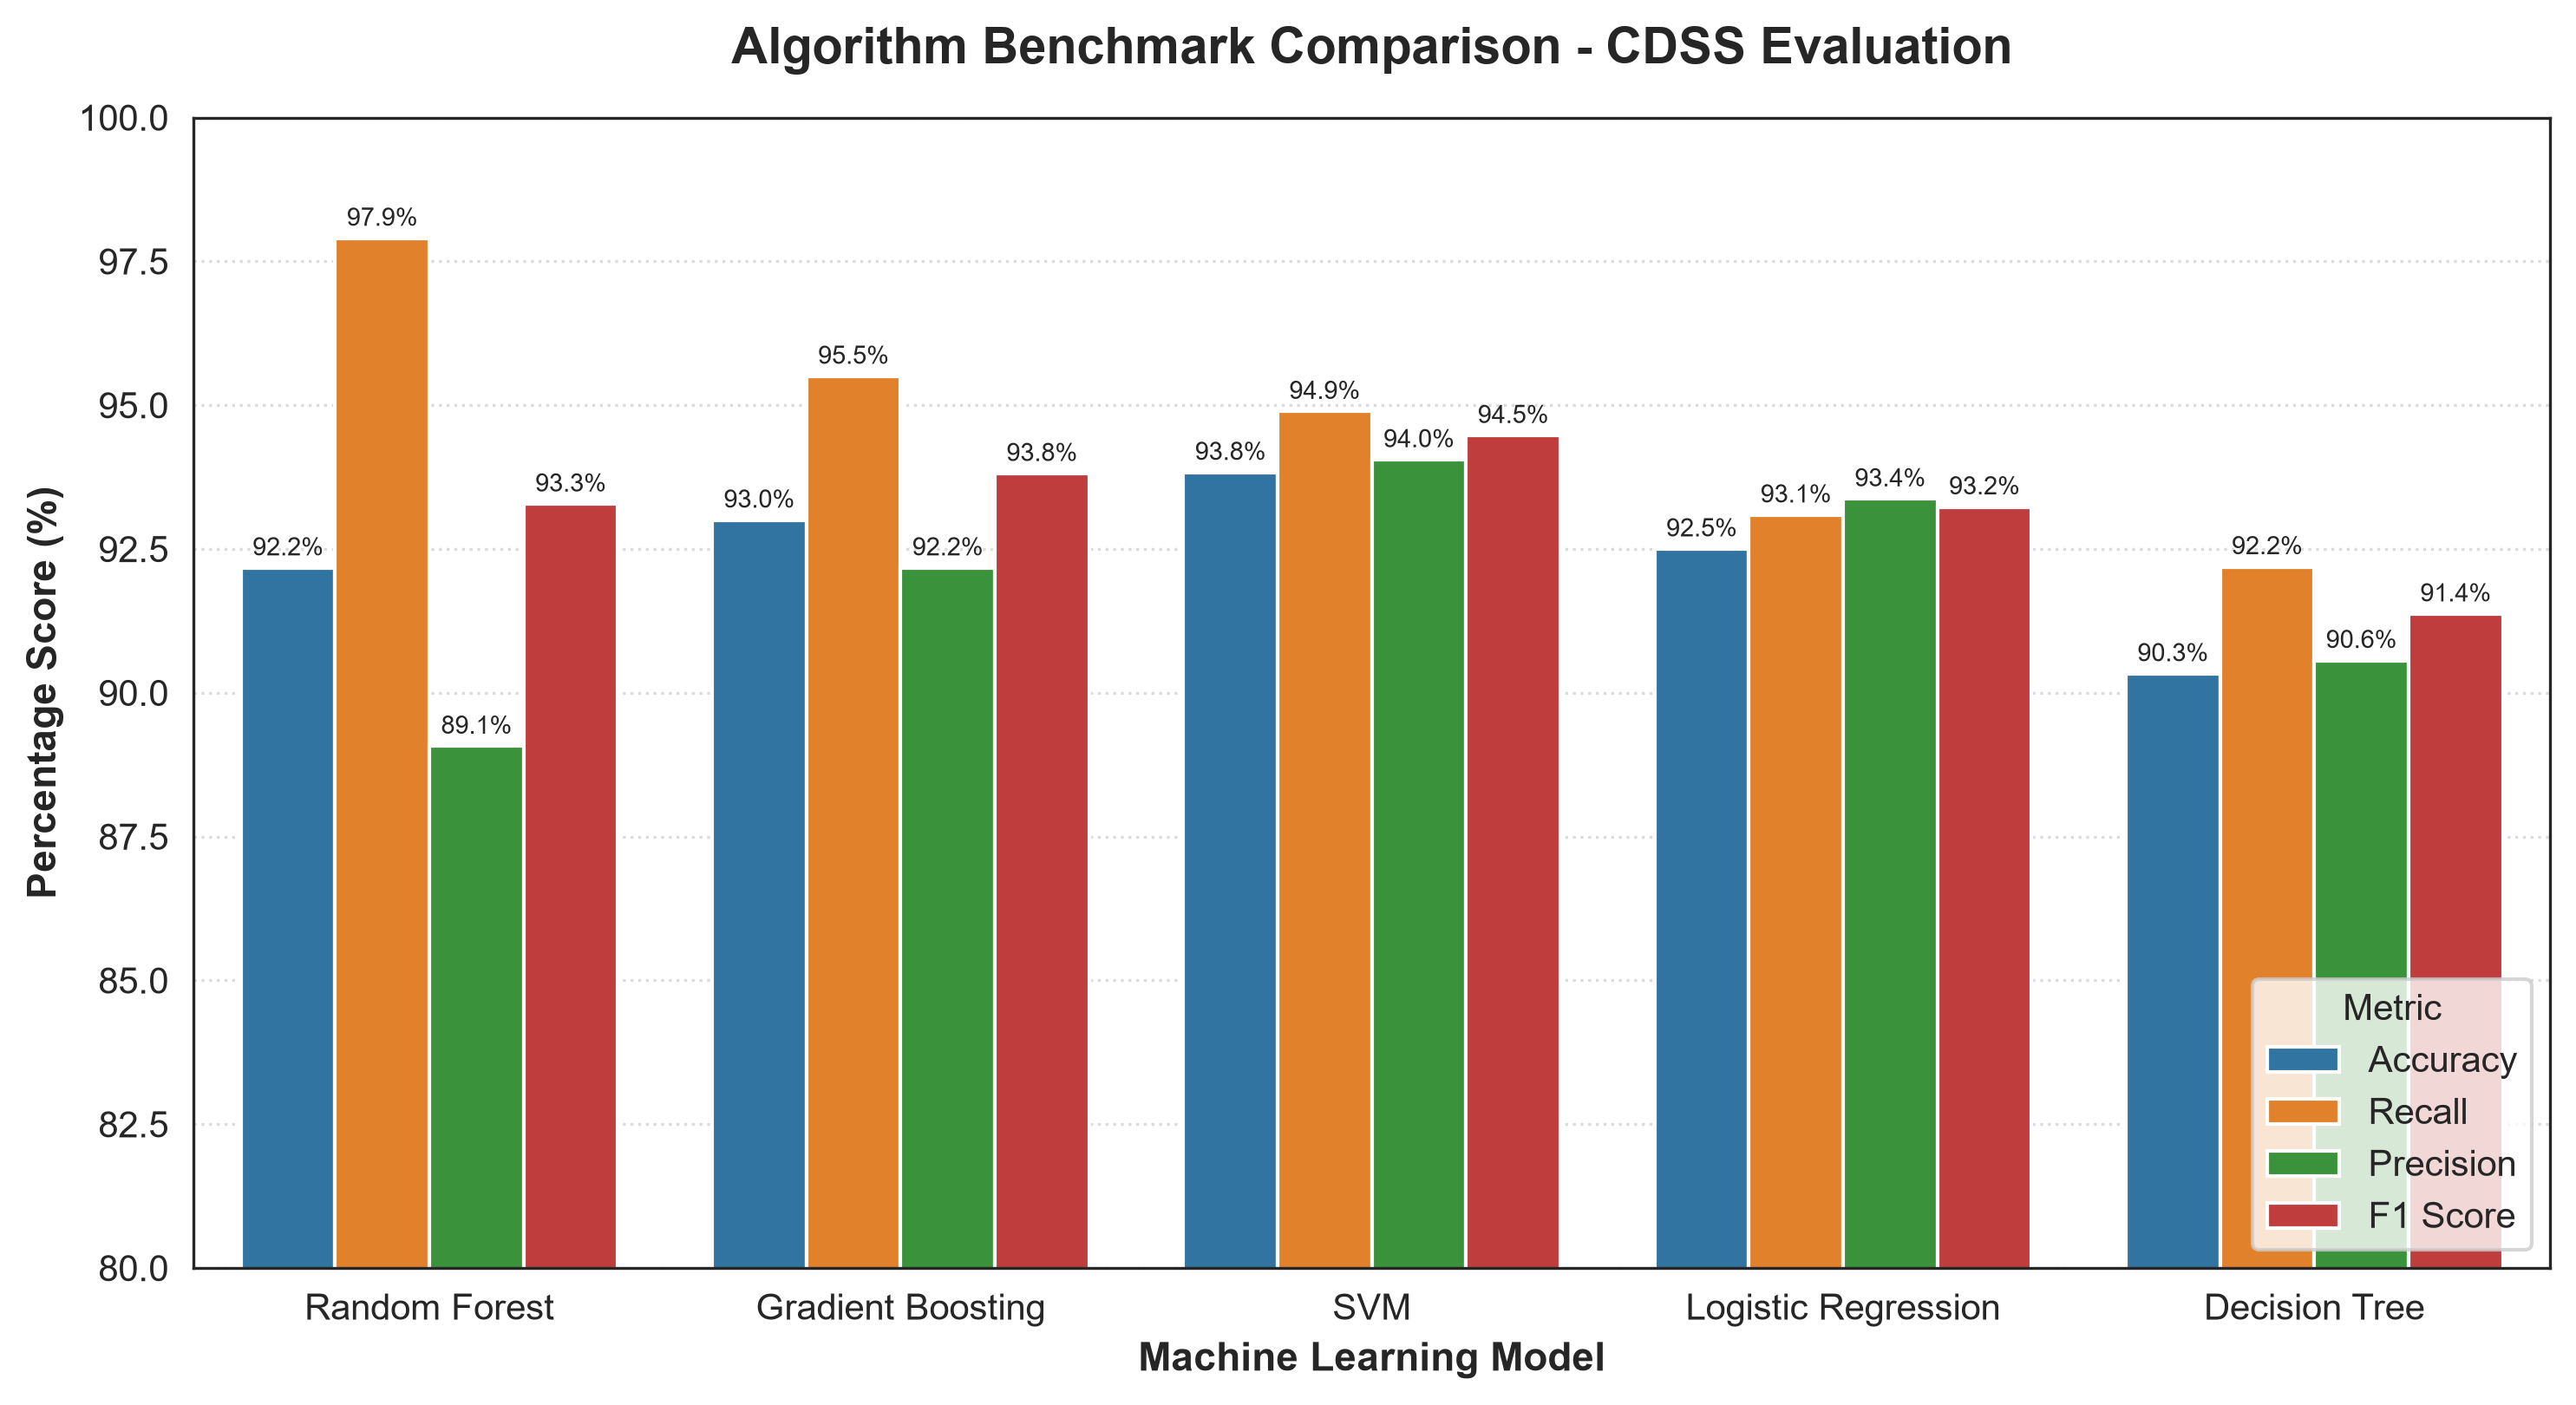

Saved high-res image: models/model_comparison_bar_chart_ppt.png


In [10]:
import pandas as pd

# Experimental performance comparison data
model_results = pd.DataFrame(
    {
        "Model": [
            "Random Forest",
            "Gradient Boosting",
            "SVM",
            "Logistic Regression",
            "Decision Tree",
        ],
        "Accuracy": [92.17, 93.00, 93.83, 92.50, 90.33],
        "Recall": [97.90, 95.50, 94.89, 93.09, 92.19],
        "Precision": [89.07, 92.17, 94.05, 93.37, 90.56],
        "F1 Score": [93.28, 93.81, 94.47, 93.23, 91.37],
    }
)

df_melted = pd.melt(
    model_results, id_vars="Model", var_name="Metric", value_name="Score"
)

plt.figure(figsize=(10, 5.5), dpi=300)
ax = sns.barplot(
    data=df_melted, x="Model", y="Score", hue="Metric", palette="tab10"
)

plt.title(
    "Algorithm Benchmark Comparison - CDSS Evaluation",
    fontsize=14,
    weight="bold",
    pad=15,
)
plt.ylabel("Percentage Score (%)", fontsize=11, weight="bold")
plt.xlabel("Machine Learning Model", fontsize=11, weight="bold")
plt.ylim(80, 100)
plt.legend(title="Metric", loc="lower right")
plt.grid(axis="y", linestyle=":", alpha=0.7)

# Add highlight arrow or box on Random Forest Recall
for p in ax.patches:
    if p.get_height() > 0:
        height = p.get_height()
        ax.annotate(
            f"{height:.1f}%",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            fontsize=7,
            xytext=(0, 2),
            textcoords="offset points",
        )

plt.tight_layout()
plt.savefig(
    "models/model_comparison_bar_chart_ppt.png", dpi=300, bbox_inches="tight"
)
plt.show()
print("Saved high-res image: models/model_comparison_bar_chart_ppt.png")

C:\Users\sivas\AppData\Local\Temp\ipykernel_16552\1986709381.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


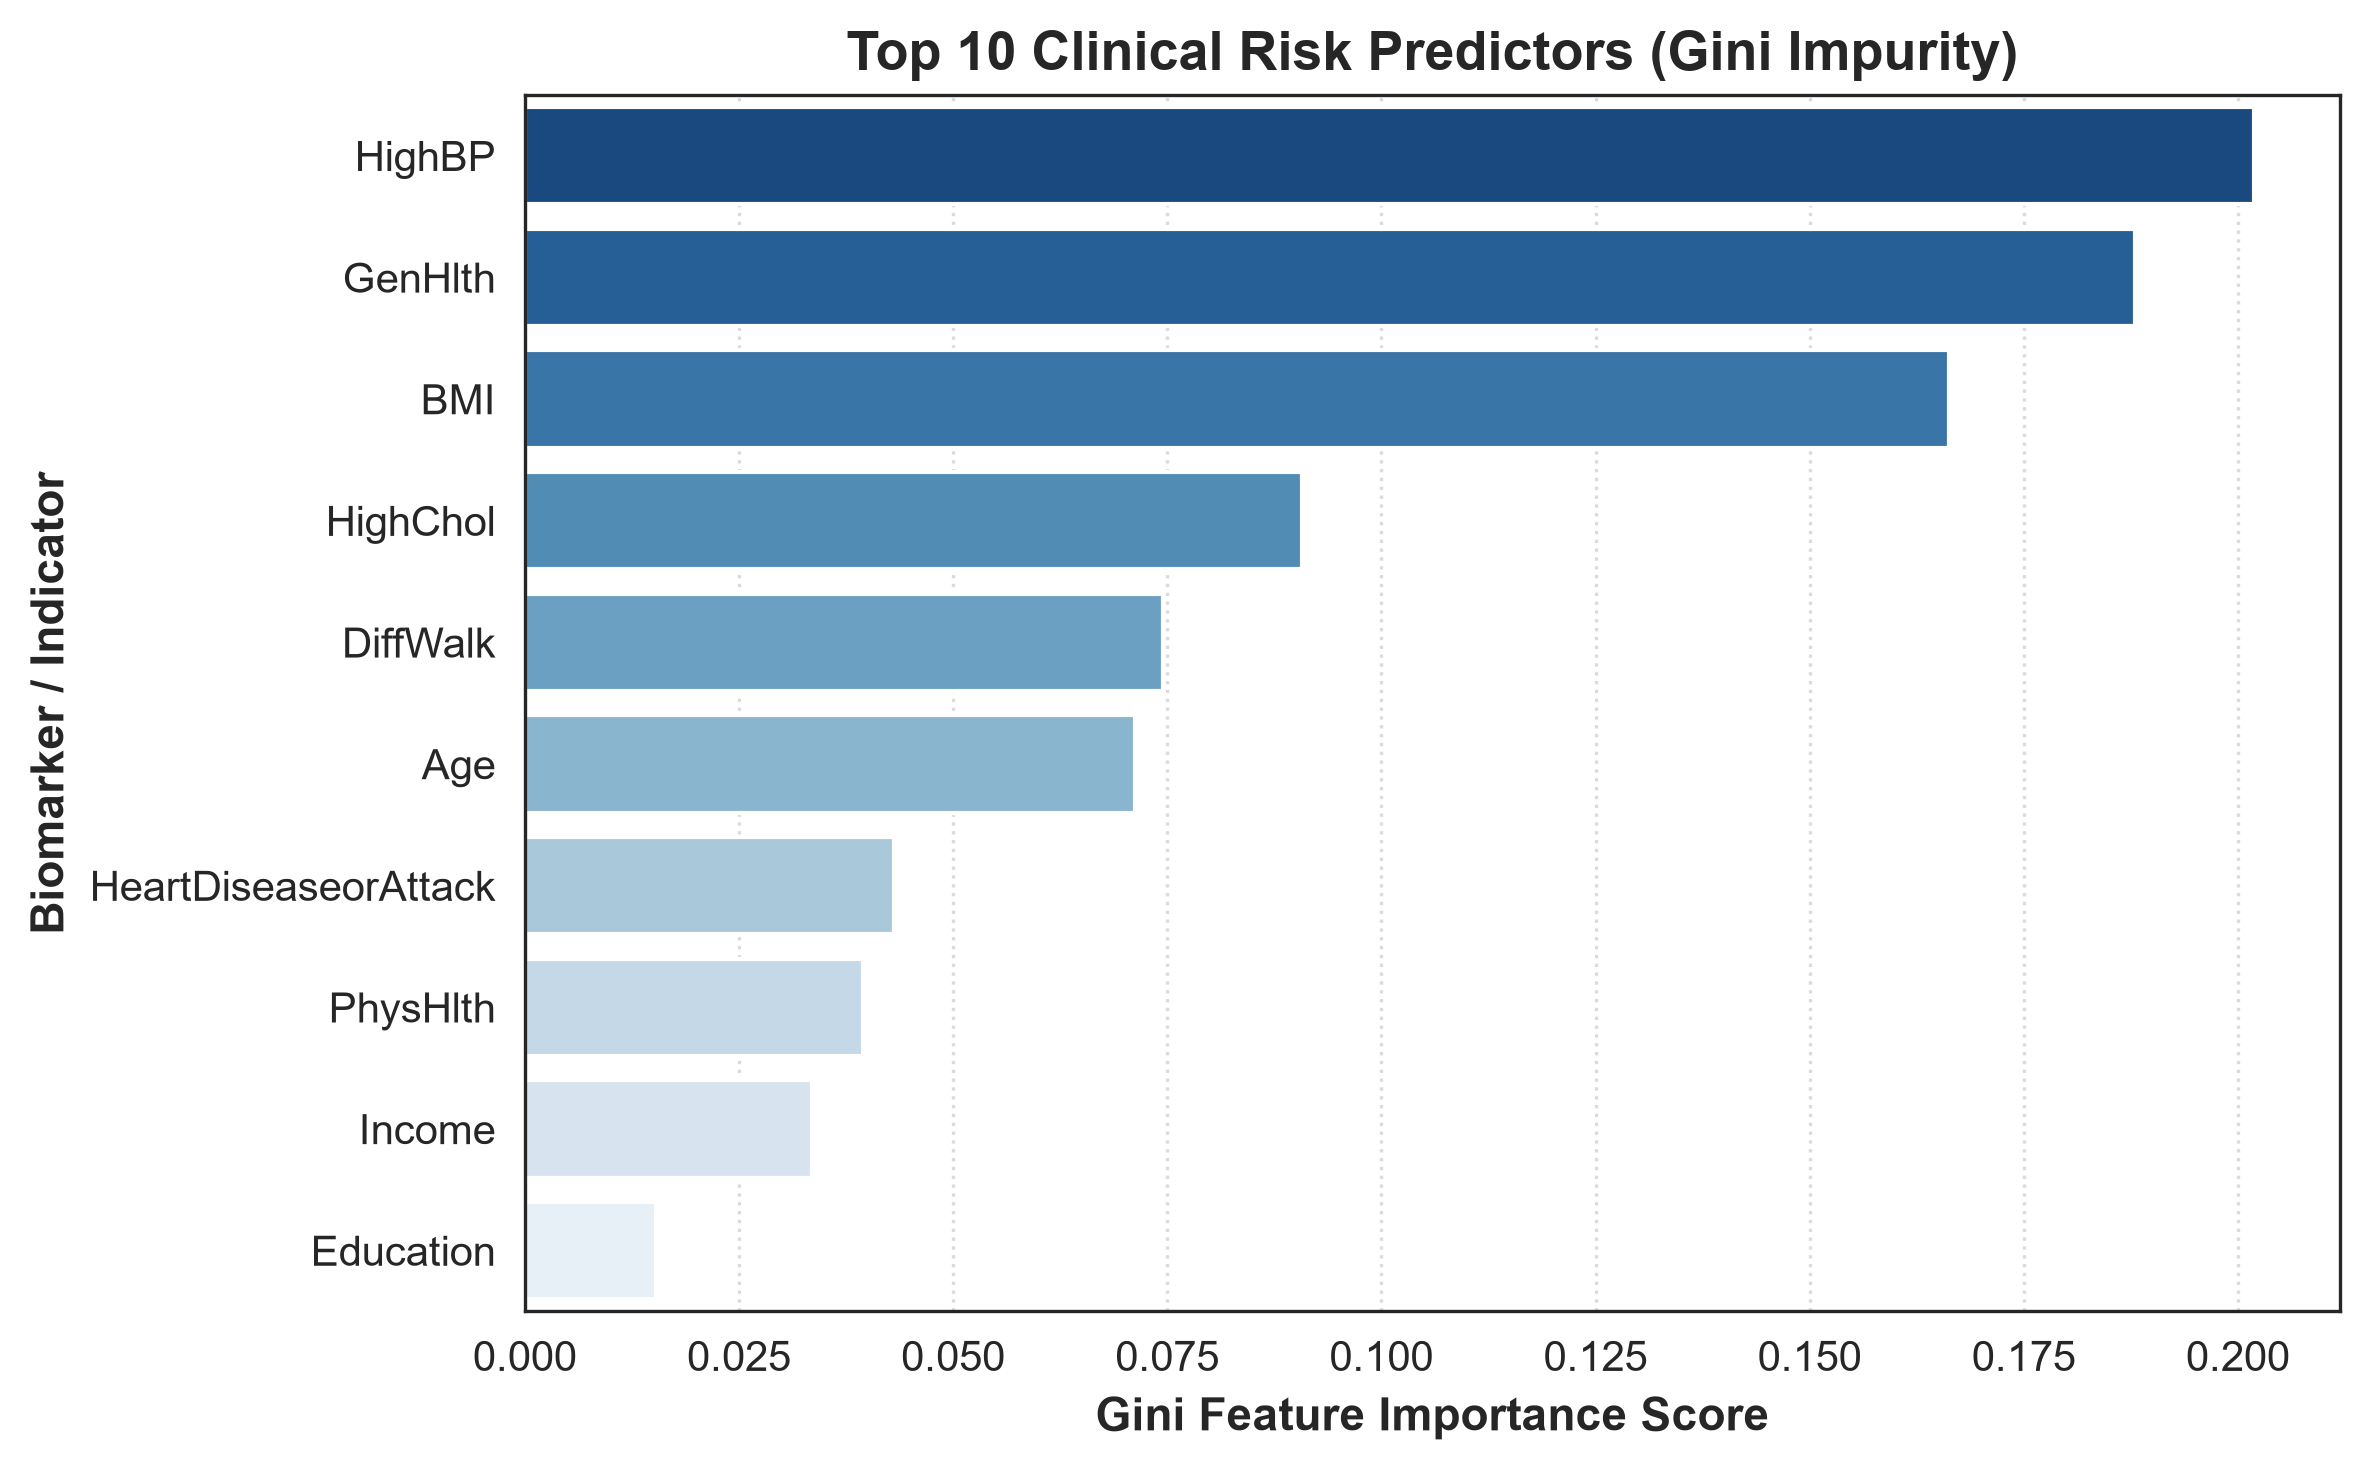

Saved high-res image: models/top10_feature_importance_ppt.png


In [11]:
# Compute Feature Importance
importances = rf_model.feature_importances_
feature_names = X.columns

feature_imp_df = (
    pd.DataFrame(
        {"Feature": feature_names, "Importance": importances}
    )
    .sort_values(by="Importance", ascending=False)
    .head(10)
)

plt.figure(figsize=(8, 5), dpi=300)
sns.barplot(
    data=feature_imp_df, x="Importance", y="Feature", palette="Blues_r"
)

plt.title("Top 10 Clinical Risk Predictors (Gini Impurity)", fontsize=13, weight="bold")
plt.xlabel("Gini Feature Importance Score", fontsize=11, weight="bold")
plt.ylabel("Biomarker / Indicator", fontsize=11, weight="bold")
plt.grid(axis="x", linestyle=":", alpha=0.7)

plt.tight_layout()
plt.savefig("models/top10_feature_importance_ppt.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved high-res image: models/top10_feature_importance_ppt.png")